#### PROBLEM STATEMENT
The Problem: African nations, particularly economic hubs like Nigeria, are experiencing severe economic volatility and stagnation driven by systemic issues such as a poor ease of doing business, capital flight, and underfunded social sectors. The challenge is to accurately predict GDP growth based on underlying developmental indicators.

Why it is Important: Economic policies often rely on lagging indicators. Understanding exactly which factors (e.g., healthcare infrastructure, education access, foreign direct investment) have the highest predictive power for GDP growth allows for proactive, targeted interventions rather than reactive measures.

Expected Impact: By building a predictive Machine Learning model, this project will identify the strongest leading indicators of economic health in Africa, providing a data-driven blueprint that policymakers and investors can use to prioritize structural reforms and stabilize the economy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Evaluating all the Datasets in this project and using the one relevant to this task , and reason why it has been selected

In [3]:
df1 = pd.read_csv('WDICSV.csv')
df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.747222,35.240236,NaN,NaN


In [4]:
df2 = pd.read_csv('WDICountry.csv')
df2.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,The reporting period for national accounts dat...,Middle East & North Africa,Low income,AF,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,Multiple Indicator Cluster Survey 2022-2023,"Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2018.0,NaN
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,"22 countries, stretching from the westernmost ...",NaN,NaN,ZI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,The World Bank systematically assesses the app...,Sub-Saharan Africa,Lower middle income,AO,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,Demographic and Health Survey 2015/16,"Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2018.0,NaN


In [5]:
df3 = pd.read_csv('WDISeries.csv')
df3.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,% (ratio),Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors, such as the green revolution, have le...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,kg per hectare of arable land,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors, such as the green revolution, have le...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the land area that...,square kilometers (sq. km),Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agricultural land constitutes onl...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,% (share) of land area,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agriculture is still a major sect...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,hectares,Annual,NaN,Areas of former states are included in the suc...,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Temporary fallow land refers to l...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [6]:
df4 = pd.read_csv('WDIcountry-series.csv')
df4.head()

,CountryCode,SeriesCode,DESCRIPTION
0,ABW,EG.EGY.PRIM.PP.KD,Sources: Estimated based on UN Energy Statisti...
1,ABW,ST.INT.RCPT.CD,Compiled from data reported in the Internation...
2,ABW,IT.CEL.SETS.P2,Servicio di Telecomunicacion di Aruba (SETAR)....
3,ABW,SP.DYN.CBRT.IN,"Data source: Central Bureau of Statistics, Uni..."
4,ABW,SP.DYN.LE00.IN,Data source: United Nations World Population P...


In [7]:
df5 = pd.read_csv('WDIfootnote.csv')
df5.head()

,CountryCode,SeriesCode,Year,DESCRIPTION
0,ABW,PA.NUS.PRVT.PP,YR2018,ICP time series PPP estimate
1,ABW,PA.NUS.PRVT.PP,YR2019,ICP time series PPP estimate
2,ABW,PA.NUS.PRVT.PP,YR2020,ICP time series PPP estimate
3,ABW,PA.NUS.PRVT.PP,YR2021,ICP benchmark PPP
4,ABW,SE.PRM.NINT.FE.ZS,YR2005,UIS estimate


In [8]:
df6 = pd.read_csv('WDIseries-time.csv')
df6.head()

,SeriesCode,Year,DESCRIPTION
0,SP.UWT.TFRT,YR1990,Averages for regions/groups are based on count...
1,SP.REG.DTHS.ZS,YR1990,Averages for regions/groups are based on count...
2,SP.DYN.WFRT,YR1990,Averages for regions/groups are based on count...
3,SP.DYN.CONU.ZS,YR1990,Averages for regions/groups are based on count...
4,SP.DYN.CONM.ZS,YR1990,Averages for regions/groups are based on count...


##### Reason for keeping some datasets and discarding some(With resepct to the task on ground)

- The WDICSV dataset file contains the actual raw numbers for every country and year. It is the real goldmine, so it should be kept.
- The WDICountry dataset file contains the Region column, which is the only way to filter out non-African countries.It is the Country metadata so it should be kept.(recall we want to predict the GDP growth of countires in the African Continent alone,and not the entire globe).
- The WDISeries dataset file translates ununderstandable and unreadable codes (like EG.ELC.ACCS.RU.ZS) into real words. It is the indicator dictionary, so it should be kept.

- TheWDIcountry-series dataset file just shows us which countries have which series. df1 already shows this. So it is therefore redundant and should be dropped.
- The WDIfootnote dataset file just shows us text sentences about data anomalies, and this is totally useless for Machine learning modelling, so it should be dropped.
- The WDIseries-time dataset file just shows us minor text notes about old regional averages, and thus, it should be dropped.

In [9]:
#So lets delete the irrelevant datasets or dataframes ,beofre we move on using the Garbage Collector library

In [10]:
import gc

del df4, df5, df6

# Force immediate cleanup
gc.collect()

20

In [11]:
#The function below gives us the corresponding indicator name for the series code it corresponds to or aligns with

In [12]:
def lookup_code(code):
    # Search df3's Series Code column and pull the corresponding Indicator Name
    match = df3[df3['Series Code'] == code]['Indicator Name'].values
    return match[0] if len(match) > 0 else "Code not found"

# Quick test run:
print(lookup_code('NE.CON.GOVT.CD'))

General government final consumption expenditure (current US$)


##### Subsetting or Narrowing our attention to only African countries

In [13]:
df2['Region'].unique()

array(['Latin America & Caribbean', nan, 'Middle East & North Africa',
       'Sub-Saharan Africa', 'Europe & Central Asia',
       'East Asia & Pacific', 'South Asia', 'North America'], dtype=object)

In [14]:
# Define the two World Bank regions that cover the African continent
african_regions = ['Sub-Saharan Africa', 'Middle East & North Africa']

In [15]:
#Creating the mask that narrows down our focus to african region alone (This generates a list of True/False values)
is_african_mask = df2['Region'].isin(african_regions)

#Applying the mask to df2, then extracting the unique country codes
african_codes = df2[is_african_mask]['Country Code'].unique()

In [16]:
african_codes

array(['AFG', 'AGO', 'ARE', 'BDI', 'BEN', 'BFA', 'BHR', 'BWA', 'CAF',
       'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY',
       'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'IRN',
       'IRQ', 'ISR', 'JOR', 'KEN', 'KWT', 'LBN', 'LBR', 'LBY', 'LSO',
       'MAR', 'MDG', 'MLI', 'MLT', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM',
       'NER', 'NGA', 'OMN', 'PAK', 'PSE', 'QAT', 'RWA', 'SAU', 'SDN',
       'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'SYR', 'TCD',
       'TGO', 'TUN', 'TZA', 'UGA', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype=object)

In [17]:
len(african_codes)

71

##### 
From the result of the mask createed,we can see that the number of countries which our mask subsetted to the African continent is incorrect because in the african continent, there ae 54 recognized countires, but our mask tells us there are 71 countries,and this error has nothing to do with the mask created. It all buoys down to the method and means by which the World Bank collated this data and didn't specify the african continent directly,but classifed them with the middle east countries.
You can see some middle east countries,for example(ARE- United Arab Emirates, ISR- Israel, IRQ- Iraq, IRN- Iran) etc which are not under the African continent but under the Middle East Region.
The implicaton of leaving these oil-rich Middle Eastern nations in the dataset is that the machine learning model will get horribly confused. It will think the "African" economy behaves like the economy of Dubai or Qatar, which defeats the entire purpose of the task in view.
So,the best thing to do is to manually hardcode all country codes that are in the african region in a list.

In [18]:
african_54 = [
    'DZA', 'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD',
    'COM', 'COD', 'COG', 'DJI', 'EGY', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB',
    'GMB', 'GHA', 'GIN', 'GNB', 'CIV', 'KEN', 'LSO', 'LBR', 'LBY', 'MDG',
    'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA',
    'STP', 'SEN', 'SYC', 'SLE', 'ZAF', 'SOM', 'SSD', 'SDN', 'TZA', 'TGO',
    'TUN', 'UGA', 'ZMB', 'ZWE'
]

In [19]:
df1['Country Code'].nunique()

266

In [20]:
df2['Country Code'].nunique()

265

In [21]:
##Filtering the main numerical dataset (df1) to keep ONLY those countries in the african region
df_africa_raw = df1[df1['Country Code'].isin(african_54)]

In [22]:
df_africa_raw.sample(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
241970,Libya,LBY,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,449.958507,431.576611,414.089208,399.158119,388.023381,...,1.055468e+02,1.038765e+02,1.022039e+02,1.007045e+02,9.935562e+01,9.810551e+01,9.690184e+01,NaN,NaN,NaN
276265,Namibia,NAM,Tax revenue (current LCU),GC.TAX.TOTL.CN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.679733e+10,5.371462e+10,5.238580e+10,5.507557e+10,5.437414e+10,5.143913e+10,5.585071e+10,7.544773e+10,NaN,NaN
366237,Tunisia,TUN,Interest payments (% of expense),GC.XPN.INTP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_africa_raw['Indicator Code'].nunique()

1486

The indicator codes that are defined here relates to several aspects and sectors(some defined for electricity, clean fuels, technologies, water productivity, Government expenditure etc), and Since we are zooming our focus to the GDP Of African Nation, we need to explicitly select the indicator codes that are directly related to or can give information about a country's GDP.

### DATA COLLECTION & UNDERSTANDING

In [24]:
# STEP 1: TRANSFORM THE DATA (MELT & PIVOT) - This converts years from columns into rows, and indicators into columns.
year_columns = df_africa_raw.columns[4:] 
df_melted = pd.melt(df_africa_raw, 
                    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], 
                    value_vars=year_columns, 
                    var_name='Year', 
                    value_name='Value')

df_pivoted = df_melted.pivot_table(index=['Country Name', 'Country Code', 'Year'], 
                                   columns='Indicator Name', 
                                   values='Value').reset_index()

# Drop rows where we don't have the final answer (GDP)
df_pivoted.dropna(subset=['GDP growth (annual %)'], inplace=True)

# STEP 2: QUALITY CONTROL (THE 30% RULE) - Calculate missing data and keep only reliable columns.
missing_data_pct = (df_pivoted.isna().sum() / len(df_pivoted)) * 100
reliable_columns = missing_data_pct[missing_data_pct < 30.0].index

# STEP 3: FILTER FOR ECONOMIC HEAVYWEIGHTS - Search our reliable columns for specific economic terms.
keywords =['GDP growth', 'electricity', 'inflation', 'trade', 'agriculture', 'investment', 'debt', 'remittances', 'education', 'health']
print("FINAL ECONOMIC FEATURES PASSING THE 30% QUALITY BENCHMARK:\n")
print(f"{'Indicator Name':<60} | {'Missing %':<10}")
print("-" * 75)

# Find and print the reliable economic columns
final_candidates = []
for col in reliable_columns:
    if any(word.lower() in col.lower() for word in keywords):
        print(f"{col[:58]:<60} | {missing_data_pct[col]:.2f}%")
        final_candidates.append(col)

# Create the final, clean dataset using only these candidates
df_final_cleaned = df_pivoted[['Country Name', 'Country Code', 'Year'] + final_candidates]

FINAL ECONOMIC FEATURES PASSING THE 30% QUALITY BENCHMARK:

Indicator Name                                               | Missing % 
---------------------------------------------------------------------------
Adjusted savings: education expenditure (% of GNI)           | 15.95%
Adjusted savings: education expenditure (current US$)        | 23.02%
Agriculture, forestry, and fishing, value added (% of GDP)   | 16.44%
Agriculture, forestry, and fishing, value added (annual %    | 25.57%
Agriculture, forestry, and fishing, value added (constant    | 25.15%
Agriculture, forestry, and fishing, value added (constant    | 24.28%
Agriculture, forestry, and fishing, value added (current L   | 16.44%
Agriculture, forestry, and fishing, value added (current U   | 16.44%
Debt service on external debt, public and publicly guarant   | 19.57%
Debt service on external debt, total (TDS, current US$)      | 19.12%
External debt stocks (% of GNI)                              | 21.21%
External debt stocks

In [25]:
df_final_cleaned.sample(4)

Indicator Name,Country Name,Country Code,Year,Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (annual % growth)","Agriculture, forestry, and fishing, value added (constant 2015 US$)","Agriculture, forestry, and fishing, value added (constant LCU)","Agriculture, forestry, and fishing, value added (current LCU)",...,"Multilateral debt service (TDS, current US$)",Nitrous oxide (N2O) emissions from Agriculture (Mt CO2e),"Personal remittances, paid (current US$)","Primary education, duration (years)","Primary education, pupils",Public and publicly guaranteed debt service (% of GNI),"Secondary education, duration (years)",Short-term debt (% of total external debt),Total debt service (% of GNI),Trade (% of GDP)
1537,Guinea,GIN,1979,1.400000,NaN,NaN,NaN,NaN,NaN,NaN,...,9418000.0,0.6241,NaN,6.0,252100.0,1.131999,6.0,9.8835,1.202549,NaN
151,Benin,BEN,1979,3.299570,3.918013e+07,34.992886,4.749883,6.012537e+08,3.554682e+11,8.830000e+10,...,1765587.6,0.4558,1.842784e+06,6.0,338948.0,0.546466,7.0,21.5520,0.549404,54.538168
2848,Sierra Leone,SLE,1970,2.995526,1.275032e+07,25.993829,2.040461,4.624469e+08,3.205156e+09,9.410000e+04,...,374000.0,0.1380,NaN,7.0,NaN,3.068027,7.0,0.0000,4.336690,60.302368
374,Burundi,BDI,2004,2.834920,2.517284e+07,41.902605,-0.239338,1.119031e+09,5.281969e+11,4.222173e+11,...,53311597.4,0.4198,3.306386e+05,6.0,968488.0,6.642613,7.0,1.6614,9.950907,NaN


Before reshaping the data with melt and pivot, we were essentially guessing from the outside. The raw World Bank file looked like a long list of country–indicator pairs, but it did not actually show how those indicators lined up over time or across countries. Once we melted and pivoted the data, we could finally see which indicators had enough consistent values to be usable and which were mostly empty for African countries. That process made something very clear: in data science, theory alone is not enough. You can have a perfect economic idea of what should drive GDP, but if the historical data structure does not support those variables, the model will never be reliable.

If you also observe in the cleaned dataframe, after the melt and pivot, we can also see that the years(from 1960 to 2025) which was found in the datafram that subbsetted the regions to only africa alone, the year column here is now a single column.

In [26]:
df_final_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3097 entries, 1 to 3562
Data columns (total 36 columns):
 #   Column                                                                                  Non-Null Count  Dtype  
---  ------                                                                                  --------------  -----  
 0   Country Name                                                                            3097 non-null   object 
 1   Country Code                                                                            3097 non-null   object 
 2   Year                                                                                    3097 non-null   object 
 3   Adjusted savings: education expenditure (% of GNI)                                      2603 non-null   float64
 4   Adjusted savings: education expenditure (current US$)                                   2384 non-null   float64
 5   Agriculture, forestry, and fishing, value added (% of GDP)                

##### Downsizing the Dataset

The main reason for downsizing this dataset is to ensure that multicollinearity is eliminated entirely.
For example, The Agriculture, Forestry and Fishing(it has about 5 distinct columns and they all are almost saying the same thing. Also, The External Debt Stock has about 5 seperate columns also. So the solution here is to pick the columns(the exact normalized columns) that tends to give us a rich amount of information amongst those that are duplicated or repeated. 
This also ensures that the model gets a rich, wholesome, and non-redundant view of how an African country is performing.

#### DATA CLEANING AND PREPROCESSING

In [27]:
#Selecting only the absolute best, normalized representative for each economic factor
curated_columns = [
    'Country Name', 'Country Code', 'Year',
    'GDP growth (annual %)',                                      #TARGET
    'Agriculture, forestry, and fishing, value added (% of GDP)', #PRODUCTION
    'Adjusted savings: education expenditure (% of GNI)',         #HUMAN CAPITAL
    'External debt stocks (% of GNI)',                           #DEBT BURDEN
    'Foreign direct investment, net inflows (% of GDP)',        #EXTERNAL CAPITAL
    'Inflation, consumer prices (annual %)',                    #VOLATILITY
    'Trade (% of GDP)',                                           #OPENNESS
    'Total debt service (% of GNI)'                              #FISCAL HEALTH
]

#Creating the new dataframe after downsizing
df = df_final_cleaned[curated_columns].copy()

#Renaming the column names for easy readability and understandability.
df.columns = ['Country', 'Code', 'Year', 'GDP_Growth', 'Agriculture_GDP', 'Education_GNI', 
              'Externaldebt_GNI', 'FDI_GDP', 'Inflation', 'Trade_GDP', 'Debt_GNI']

##### Why Normalized Data For Africa?

Here is Why "Normalized" Data Matters for Africa
The secret expo in the list of the final economic features selected is that almost every metric is expressed as a percentage (% of GDP or % of GNI) rather than a raw number in US Dollars.

If you used raw numbers, Nigeria's or South Africa's multi-billion dollar figures would completely overwhelm the model, making it impossible to predict GDP growth for smaller nations like Cabo Verde, Rwanda, or Seychelles.

In [28]:
#CHRONOLOGICAL TIME-SERIES IMPUTATION
#Sort chronologically so forward-filling moves correctly from past to present
df_clean = df.sort_values(by=['Country', 'Year'])

#List of predictor columns that contain NaN values that needs to be filled
feature_cols = ['Agriculture_GDP', 'Education_GNI', 'Externaldebt_GNI', 'FDI_GDP', 'Inflation', 'Trade_GDP', 'Debt_GNI']

#Group by country and forward-fill (carry last year's data forward if this year is missing)
#Then backward-fill (if the very first year is missing, pull from the next available year)
df_clean[feature_cols] = df_clean.groupby('Country')[feature_cols].bfill().ffill()

In [29]:
df_clean.sample(5)

,Country,Code,Year,GDP_Growth,Agriculture_GDP,Education_GNI,Externaldebt_GNI,FDI_GDP,Inflation,Trade_GDP,Debt_GNI
902,Cote d'Ivoire,CIV,2004,3.185038,16.640019,4.320000,89.108851,1.203628,1.457988,58.118296,2.649640
2727,Senegal,SEN,1981,5.180230,20.663623,3.700000,41.909124,0.839186,5.913194,65.851922,4.586050
2808,Seychelles,SYC,1996,9.997946,3.636484,6.500000,150.690164,5.383084,-1.100244,98.055343,10.802251
3145,Sudan,SDN,2003,6.288808,38.416611,1.470000,84.687721,6.317823,6.489432,26.440228,1.355560
2936,"Somalia, Fed. Rep.",SOM,1992,-8.488323,55.794183,0.991145,338.171661,-0.008459,28.633750,88.573646,0.035599


In [30]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3097 entries, 1 to 3562
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           3097 non-null   object 
 1   Code              3097 non-null   object 
 2   Year              3097 non-null   object 
 3   GDP_Growth        3097 non-null   float64
 4   Agriculture_GDP   3097 non-null   float64
 5   Education_GNI     3097 non-null   float64
 6   Externaldebt_GNI  3097 non-null   float64
 7   FDI_GDP           3097 non-null   float64
 8   Inflation         3097 non-null   float64
 9   Trade_GDP         3097 non-null   float64
 10  Debt_GNI          3097 non-null   float64
dtypes: float64(8), object(3)
memory usage: 290.3+ KB


In [31]:
df_clean.isnull().sum()

Country             0
Code                0
Year                0
GDP_Growth          0
Agriculture_GDP     0
Education_GNI       0
Externaldebt_GNI    0
FDI_GDP             0
Inflation           0
Trade_GDP           0
Debt_GNI            0
dtype: int64

In [32]:
df_clean.duplicated().sum()

np.int64(0)

As for the Year Column, we would need to convert its datatype from object into Datetime because this is a standard time-series data, where there are days,hours, months etc. But for this case of the World Bank Data, the world bank only traces data once every year(annually), so converting it into datetime would make it unable for the models to read raw datetime objects.(eg converting 1980 to 1980-01-01)

In [33]:
#Lets convert the year column from object datatype into integer
df_clean['Year'] = df_clean['Year'].astype(int)

In [34]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3097 entries, 1 to 3562
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           3097 non-null   object 
 1   Code              3097 non-null   object 
 2   Year              3097 non-null   int64  
 3   GDP_Growth        3097 non-null   float64
 4   Agriculture_GDP   3097 non-null   float64
 5   Education_GNI     3097 non-null   float64
 6   Externaldebt_GNI  3097 non-null   float64
 7   FDI_GDP           3097 non-null   float64
 8   Inflation         3097 non-null   float64
 9   Trade_GDP         3097 non-null   float64
 10  Debt_GNI          3097 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 290.3+ KB


In [35]:
df_clean.tail()

,Country,Code,Year,GDP_Growth,Agriculture_GDP,Education_GNI,Externaldebt_GNI,FDI_GDP,Inflation,Trade_GDP,Debt_GNI
3558,Zimbabwe,ZWE,2020,-7.816951,20.847051,1.91,49.502422,0.470482,557.201817,40.178406,3.120968
3559,Zimbabwe,ZWE,2021,8.468017,21.485653,1.91,53.005693,0.575185,98.546105,44.114559,1.494383
3560,Zimbabwe,ZWE,2022,6.139263,17.061231,1.91,44.090453,0.826254,104.705171,55.067352,1.131390
3561,Zimbabwe,ZWE,2023,5.350869,11.494869,1.91,41.810856,1.684321,104.705171,40.291261,4.181026
3562,Zimbabwe,ZWE,2024,1.742395,8.688451,1.91,32.976597,1.120461,104.705171,41.486531,3.443143


##### 
If you observe closely here, the row count from the info() method tells us there are 3097 rows,but the last 5 rows show us that the cleaned dataframe has an index numbering upto 3562, and this is due to the fact that when we carried out melt and pivot, we dropped rows that didnot have information that can translate to or lead to predicting the GDP of a nation in Africa, and while we did that, pandas didnot re-number the rows automatically. So the best thing to do here is to re-number the rows by resetting the index to avoid any form of confusion or chaos later on.

In [36]:
df_clean.reset_index(drop=True, inplace=True)

In [37]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3097.0,1994.254117,17.937544,1961.000000,1980.000000,1995.000000,2010.000000,2024.000000
GDP_Growth,3097.0,3.888075,7.523964,-51.030865,1.206641,3.989426,6.399884,149.972963
Agriculture_GDP,3097.0,25.024415,16.667358,0.892696,11.243830,23.394542,34.542144,89.414510
Education_GNI,3097.0,3.639851,2.761672,0.700000,2.247148,3.300000,4.467196,68.152930
Externaldebt_GNI,3097.0,65.223579,82.599964,0.000000,22.581996,44.310377,73.060402,1343.269962
FDI_GDP,3097.0,2.657550,7.229068,-82.892095,0.179749,1.049667,2.888142,161.823760
Inflation,3097.0,26.330994,447.103672,-17.640424,2.948877,7.136153,13.422835,23773.131774
Trade_GDP,3097.0,65.891673,34.404958,1.995412,42.942737,56.367582,83.353009,320.939230
Debt_GNI,3097.0,3.919859,4.934763,0.000000,1.000072,2.409658,4.797959,73.284255


In [38]:
df_clean['Country'].unique()

array(['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso',
       'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic',
       'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       "Cote d'Ivoire", 'Djibouti', 'Egypt, Arab Rep.',
       'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
       'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya',
       'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali',
       'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia',
       'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal',
       'Seychelles', 'Sierra Leone', 'Somalia, Fed. Rep.', 'South Africa',
       'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
       'Zambia', 'Zimbabwe'], dtype=object)

##### KEY INSIGHTS DERIVED FROM THE AFRICAN GDP DATASET (Descriptive Statistics)
1. Why Equatorial Guinea’s 149.97% GDP jump in 1997 is real (not a fluke): In the mid-1990s, Equatorial Guinea was one of Africa's smallest and poorest economies, surviving mainly on cocoa and timber exports. The discovery and immediate extraction of massive offshore oil reserves in 1995 and 1996 injected billions of dollars overnight into an economy so small that the impact was proportionally explosive. The 149.97% GDP growth recorded in 1997 remains one of the largest single-year economic expansions ever recorded in human history, and this dataset captured it exactly.
2. How inflation can reach 23,000% (hyperinflation mechanics): This figure represents hyperinflation, a collapse so severe that a government can no longer fund itself through taxes or borrowing and resorts to printing unlimited amounts of cash. As money floods the economy with no corresponding goods or services to back it, prices spiral hourly. This peak captures documented collapses in Angola during its civil war and Zimbabwe around 2007 and 2008, where citizens carried bags of cash to buy a single loaf of bread.
3. Why a government’s spending share can jump from ~4% to ~68%: No country sustains 68% of its national income as an education budget under normal governance. When this figure appears, it reflects a statistical anomaly caused by economic collapse rather than genuine educational investment. When a country's GDP shrinks catastrophically due to war, sanctions, or hyperinflation, even a fixed and modest education budget becomes an astronomical percentage of what remains of the national income.
4. Other dataset insights that reveal why people get poorer: The maximum external debt figure of 1,343% of GNI means a country owed thirteen times its entire annual national income to foreign creditors. This level of debt does not just slow growth, it makes independent economic decision-making nearly impossible. Every dollar earned goes toward servicing debt rather than building schools, hospitals, or infrastructure, trapping populations in generational poverty.

##### Dealing with outliers uisng the Winsorization Technique

In [39]:
# Creating a copy of the original dataframe so we donot tamper with the columns that donot need outlier handling or capping
df_treated = df_clean.copy()

# List the columns that are prone to wild, explosive outliers
volatile_columns = ['GDP_Growth', 'Inflation', 'Externaldebt_GNI', 'FDI_GDP', 'Trade_GDP', 'Education_GNI', 'Debt_GNI']


# Loop through each volatile column and cap the outliers at the 1st and 99th percentiles
for col in volatile_columns:
    lower_bound = df_treated[col].quantile(0.01)
    upper_bound = df_treated[col].quantile(0.99)
    
    # Clip the data: Anything below lower_bound becomes lower_bound, anything above becomes upper_bound
    df_treated[col] = df_treated[col].clip(lower=lower_bound, upper=upper_bound)

In [40]:
lower_bound, upper_bound

(np.float64(0.013743440318117545), np.float64(22.438671048640675))

In [41]:
df_treated.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3097.0,1994.254117,17.937544,1961.000000,1980.000000,1995.000000,2010.000000,2024.000000
GDP_Growth,3097.0,3.825127,5.692426,-15.751989,1.206641,3.989426,6.399884,23.753326
Agriculture_GDP,3097.0,25.024415,16.667358,0.892696,11.243830,23.394542,34.542144,89.414510
Education_GNI,3097.0,3.555503,1.769208,0.850000,2.247148,3.300000,4.467196,9.480000
Externaldebt_GNI,3097.0,63.274949,67.664181,3.041832,22.581996,44.310377,73.060402,363.013909
FDI_GDP,3097.0,2.451609,4.318865,-3.182022,0.179749,1.049667,2.888142,26.910415
Inflation,3097.0,12.341689,18.536025,-5.380178,2.948877,7.136153,13.422835,122.895704
Trade_GDP,3097.0,65.416064,31.942984,18.037893,42.942737,56.367582,83.353009,168.934535
Debt_GNI,3097.0,3.843518,4.404625,0.013743,1.000072,2.409658,4.797959,22.438671


Why Winsorization Was the Right Choice for This Dataset

Winsorization was selected over other outlier handling techniques for three reasons that are specific to this dataset and cannot be ignored. 
- First, because GDP growth and inflation are already expressed as percentages, keeping them in their original units matters. Mathematical transformations like logarithms distort those units, making it nearly impossible to explain model predictions to anyone outside a data science environment.
- Second, African macroeconomic history contains genuine negative values including recessions and deflation periods, and most mathematical transformations break down or require workarounds when confronted with negative numbers. Winsorization handles negative boundaries without any adjustments.
- Third, unlike transformations that apply a formula to every single row and warp the entire distribution, Winsorization only touches the extreme one percent of anomalies at both ends of the data, leaving the remaining ninety nine percent of the historical record completely intact and authentic. It is a surgical correction, not a wholesale rewrite of the data.

#### EXPLORATORY DATA ANALYSIS

In [42]:
df_treated.head()

,Country,Code,Year,GDP_Growth,Agriculture_GDP,Education_GNI,Externaldebt_GNI,FDI_GDP,Inflation,Trade_GDP,Debt_GNI
0,Algeria,DZA,1961,-13.605441,11.10698,5.230526,19.813578,1.647364,6.6,113.748328,0.942873
1,Algeria,DZA,1962,-15.751989,11.10698,5.230526,19.813578,1.647364,6.6,40.612519,0.942873
2,Algeria,DZA,1963,23.753326,11.10698,5.230526,19.813578,1.647364,6.6,61.510197,0.942873
3,Algeria,DZA,1964,5.839413,11.10698,5.230526,19.813578,1.647364,6.6,54.523821,0.942873
4,Algeria,DZA,1965,6.206898,11.10698,5.230526,19.813578,1.647364,6.6,48.437022,0.942873


In [43]:
num_cols = ['GDP_Growth', 'Agriculture_GDP', 'Education_GNI', 'Externaldebt_GNI', 'FDI_GDP', 'Inflation', 'Trade_GDP', 'Debt_GNI']

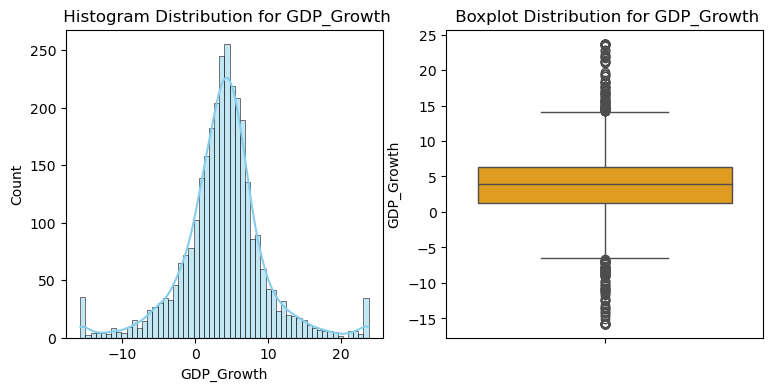

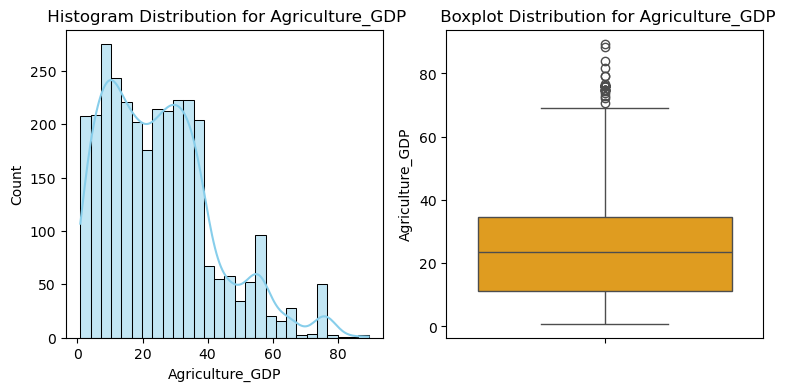

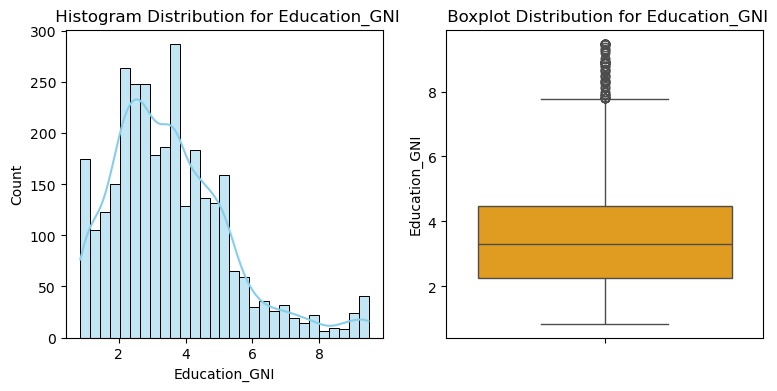

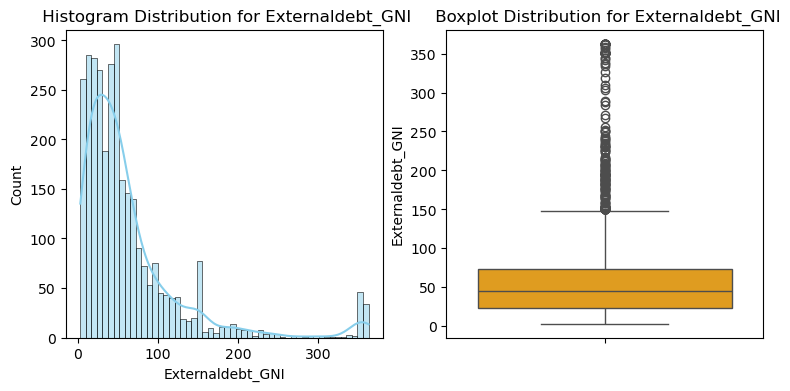

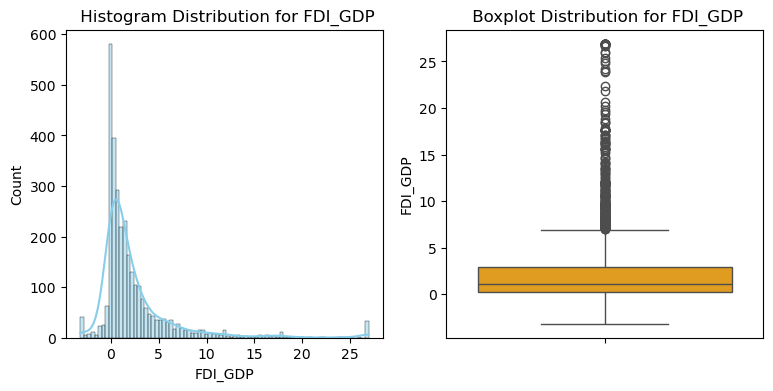

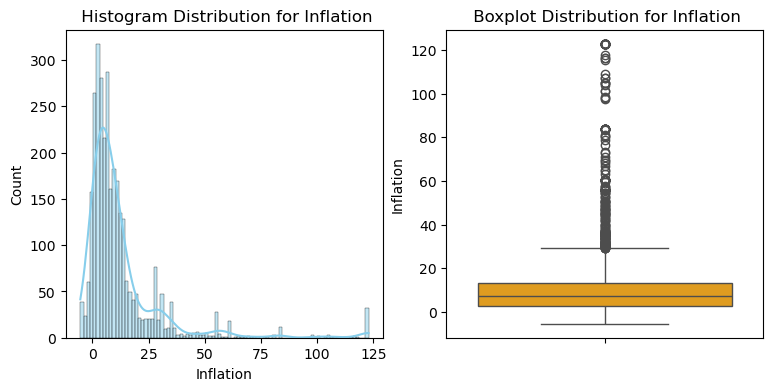

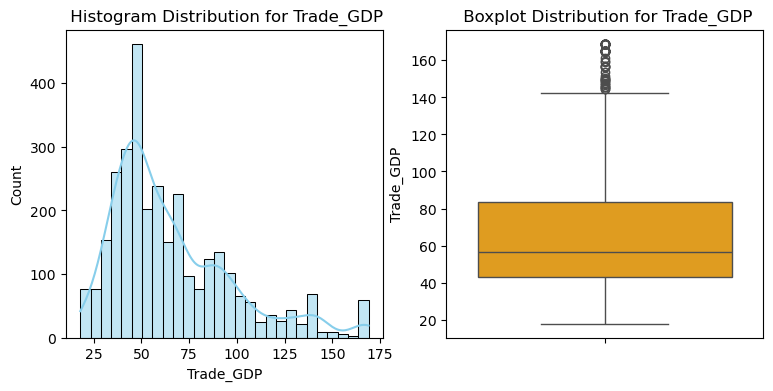

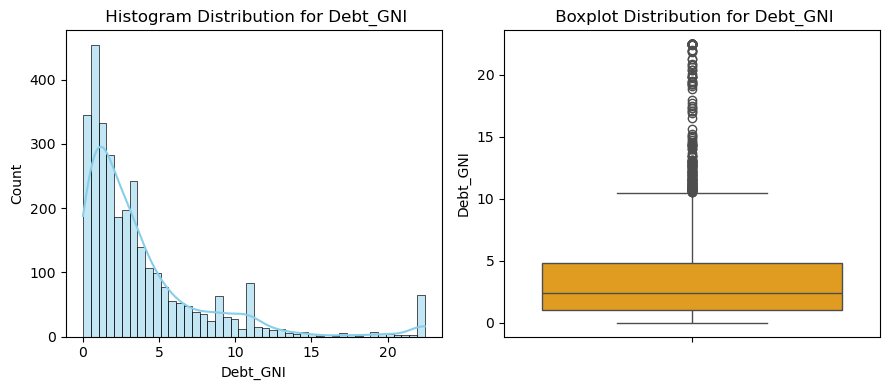

In [44]:
for col in num_cols:
    plt.figure(figsize=(9,4))
    #Histplot
    plt.subplot(1,2,1)
    sns.histplot(df_treated[col], kde=True, color='skyblue')
    plt.title(f' Histogram Distribution for {col}')
    #Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(df_treated[col], linewidth=1, color='orange')
    plt.title(f' Boxplot Distribution for {col}')

plt.tight_layout()
plt.show()

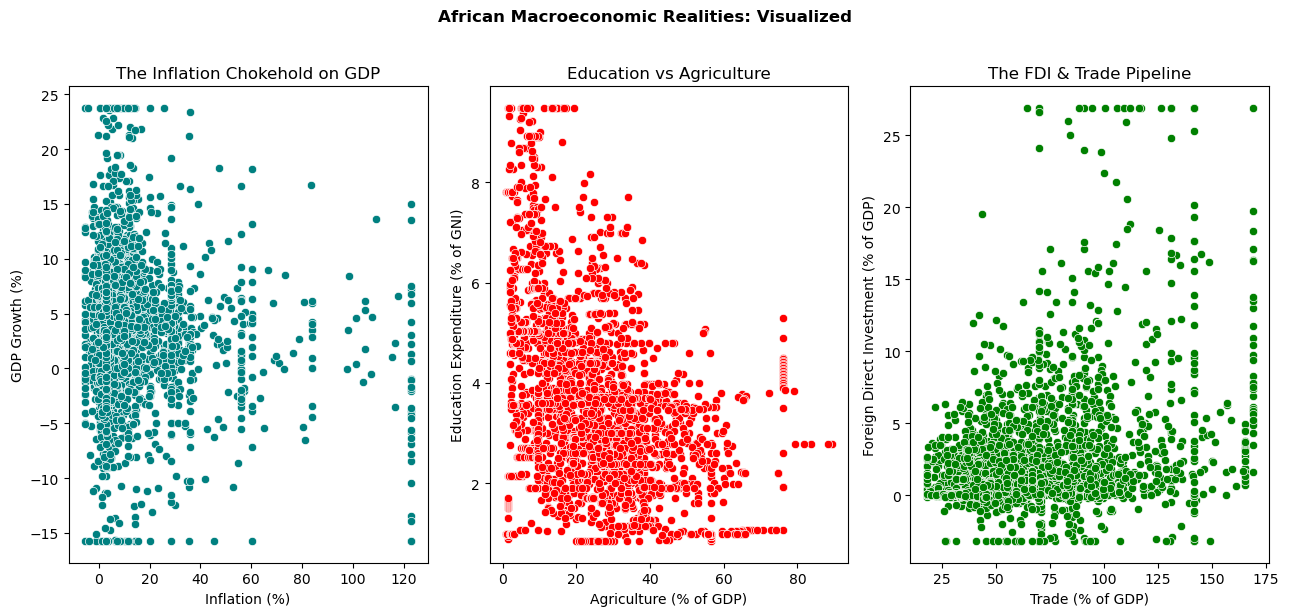

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6))
fig.suptitle("African Macroeconomic Realities: Visualized", fontsize=12, fontweight='bold', y=1.02)


#Plot 1: Scatter Plot - The Growth Chokehold
sns.scatterplot(data=df_treated, x='Inflation', y='GDP_Growth', color='teal', ax=axes[0])
axes[0].set_xlabel('Inflation (%)')
axes[0].set_ylabel('GDP Growth (%)')
axes[0].set_title('The Inflation Chokehold on GDP')

#Plot 2: Scatter Plot - Structural Transformation
sns.scatterplot(data=df_treated, x='Agriculture_GDP', y='Education_GNI', color='red', ax=axes[1])
axes[1].set_xlabel('Agriculture (% of GDP)')
axes[1].set_ylabel('Education Expenditure (% of GNI)')
axes[1].set_title('Education vs Agriculture')

#Plot 3: Scatter Plot - The Foreign Investment Pipeline
sns.scatterplot(data=df_treated, x='Trade_GDP', y='FDI_GDP', color='green', ax=axes[2])
axes[2].set_xlabel('Trade (% of GDP)')
axes[2].set_ylabel('Foreign Direct Investment (% of GDP)')
axes[2].set_title('The FDI & Trade Pipeline')

plt.tight_layout()
plt.show()

The scatterplots clearly define three major African macroeconomic trends. First, high inflation consistently limits economic growth, with rare high-growth exceptions driven by external factors like oil booms. Second, countries heavily reliant on agriculture struggle to fund education due to low tax revenues, highlighting the need for structural economic evolution. Finally, closed economies attract almost zero foreign investment, while countries that actively expand their international trade become prime targets for global capital.

In [46]:
#Correlation Matrix
correlation = df_treated[num_cols].corr()
correlation

,GDP_Growth,Agriculture_GDP,Education_GNI,Externaldebt_GNI,FDI_GDP,Inflation,Trade_GDP,Debt_GNI
GDP_Growth,1.000000,-0.047849,-0.015358,-0.108405,0.134829,-0.110885,0.082315,-0.048080
Agriculture_GDP,-0.047849,1.000000,-0.397896,-0.022776,-0.095350,0.126997,-0.302239,-0.329779
Education_GNI,-0.015358,-0.397896,1.000000,0.227531,0.058915,-0.156887,0.315095,0.391772
Externaldebt_GNI,-0.108405,-0.022776,0.227531,1.000000,0.211919,0.165230,0.274008,0.582033
FDI_GDP,0.134829,-0.095350,0.058915,0.211919,1.000000,-0.021769,0.411139,0.161722
Inflation,-0.110885,0.126997,-0.156887,0.165230,-0.021769,1.000000,-0.085337,0.020677
Trade_GDP,0.082315,-0.302239,0.315095,0.274008,0.411139,-0.085337,1.000000,0.340843
Debt_GNI,-0.048080,-0.329779,0.391772,0.582033,0.161722,0.020677,0.340843,1.000000


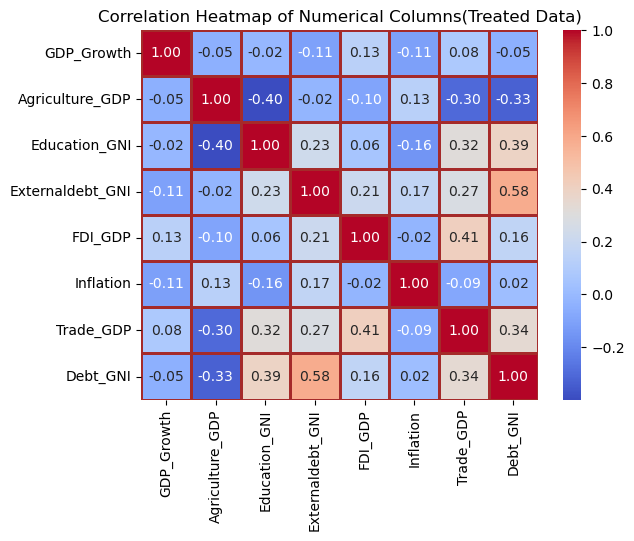

In [47]:
sns.heatmap(correlation, cmap='coolwarm', annot=True, fmt = '.2f', linewidths=1, linecolor='brown')
plt.title('Correlation Heatmap of Numerical Columns(Treated Data)')
plt.show()

##### Macroecomonic insights obtained from the Correlation Matrix
1. The Debt Trap (External Debt & Debt GNI: 0.58)
Taking on massive foreign loans immediately swallows a nation's income through heavy debt servicing.

2. The Growth Chokehold (GDP Growth vs. Inflation & Debt: -0.11)
Wild inflation and massive national debt stifle business and actively drag down overall economic growth.

3. Structural Transformation (Education vs. Agriculture: -0.40)
As a country modernizes from rural farming to urban services, its tax base grows, shifting funding into education.

4. The Trade Stabilizer (Trade vs. Inflation: -0.09)
Deep integration into global markets strengthens local currencies and helps curtail hyperinflation.

5. The Educated Debt Paradox (Education vs. Debt GNI: 0.39)
Building modern universities and educational infrastructure forces developing nations to take on massive foreign loans.

6. The Foreign Investment Pipeline (FDI & Trade: 0.41)
Global companies only invest capital into open economies where they can easily import materials and export profits.

7. The External Growth Driver (GDP Growth vs. FDI & Trade: 0.13, 0.08)
African economic booms historically rely on external capital and global markets rather than just internal sectors.

8. The Isolation of the Farmer (Agriculture vs. FDI & Trade: -0.10, -0.30)
Heavily agrarian countries remain mathematically disconnected from foreign direct investment and global trade wealth.

#### MACHINE LEARNING MODELLING

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
# We also drop 'Year' because the model should learn universal economic rules, not just memorize what happened in 1970,1995,2002,2024 etc
X = df_treated.drop(columns = ['GDP_Growth', 'Year'])
y = df_treated['GDP_Growth']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

In [51]:
X_train.shape, y_train.shape

((2477, 9), (2477,))

In [52]:
X_train.head()

,Country,Code,Agriculture_GDP,Education_GNI,Externaldebt_GNI,FDI_GDP,Inflation,Trade_GDP,Debt_GNI
2587,"Somalia, Fed. Rep.",SOM,55.794183,0.991145,102.033543,3.509979,28.633750,88.573646,0.013743
2740,Tanzania,TZA,28.954720,2.606016,6.929949,0.107666,9.777015,34.483607,0.133272
1961,Morocco,MAR,17.898437,3.600000,29.783303,0.055872,7.918289,55.818846,1.922262
2516,Sierra Leone,SLE,49.107100,2.990000,81.863506,2.733291,11.649974,46.171999,1.077705
2382,Senegal,SEN,17.831928,3.489321,63.518772,1.092993,1.156781,48.098675,5.015081


In [53]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2477 entries, 2587 to 860
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           2477 non-null   object 
 1   Code              2477 non-null   object 
 2   Agriculture_GDP   2477 non-null   float64
 3   Education_GNI     2477 non-null   float64
 4   Externaldebt_GNI  2477 non-null   float64
 5   FDI_GDP           2477 non-null   float64
 6   Inflation         2477 non-null   float64
 7   Trade_GDP         2477 non-null   float64
 8   Debt_GNI          2477 non-null   float64
dtypes: float64(7), object(2)
memory usage: 193.5+ KB


In [54]:
#Identifying Categorical and Numerical Columns
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

##### Model Building and Evaluation

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [57]:
#Numerical and Categrical Pipeines
numcols_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

catcols_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

In [58]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numcols_pipeline, numerical_cols),
    ('cat', catcols_pipeline, categorical_cols)])

In [59]:
numerical_cols

['Agriculture_GDP',
 'Education_GNI',
 'Externaldebt_GNI',
 'FDI_GDP',
 'Inflation',
 'Trade_GDP',
 'Debt_GNI']

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [61]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [62]:
#Instantiate ALL the models to be used
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Random Forest (Baseline)':      RandomForestRegressor(random_state=42),
    'Gradient Boosting':             GradientBoostingRegressor(random_state=42),
    'AdaBoost':                      AdaBoostRegressor(random_state=42)
}

In [63]:
results = {}

for name, model in models.items():
    # Dynamically create the full pipeline for the current model
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train the full pipeline
    full_pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    train_pred = full_pipeline.predict(X_train)
    test_pred = full_pipeline.predict(X_test)
    
    # Calculate performance metrics
    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test = mean_absolute_error(y_test, test_pred)
    mse_train = mean_squared_error(y_train, train_pred)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    #Print result of the models performance
    results[name] = {
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'MSE Train': mse_train,
        'MSE Test': mse_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'R2 Train': r2_train,
        'R2 Test': r2_test
    }

In [64]:
results

{'Linear Regression (Baseline)': {'MAE Train': 3.7639416227973608,
  'MAE Test': 3.601662474501261,
  'MSE Train': 29.822072396680642,
  'MSE Test': 27.920414722738702,
  'RMSE Train': np.float64(5.460958926478082),
  'RMSE Test': np.float64(5.283977169021333),
  'R2 Train': 0.09264822552260554,
  'R2 Test': 0.08396275540960918},
 'Random Forest (Baseline)': {'MAE Train': 1.475258734891475,
  'MAE Test': 3.7204518658183927,
  'MSE Train': 5.233124931775435,
  'MSE Test': 30.91374645307536,
  'RMSE Train': np.float64(2.287602441810079),
  'RMSE Test': np.float64(5.560013170224991),
  'R2 Train': 0.8407795028545084,
  'R2 Test': -0.014245074869124519},
 'Gradient Boosting': {'MAE Train': 3.335012512069176,
  'MAE Test': 3.5152425655485082,
  'MSE Train': 22.43122335919575,
  'MSE Test': 26.666966822516688,
  'RMSE Train': np.float64(4.736161247170091),
  'RMSE Test': np.float64(5.164006857326652),
  'R2 Train': 0.3175185799317405,
  'R2 Test': 0.12508696406335362},
 'AdaBoost': {'MAE Tra

In [67]:
model_results = pd.DataFrame(results)
model_results

,Linear Regression (Baseline),Random Forest (Baseline),Gradient Boosting,AdaBoost
MAE Train,3.763942,1.475259,3.335013,3.834151
MAE Test,3.601662,3.720452,3.515243,3.672768
MSE Train,29.822072,5.233125,22.431223,29.844352
MSE Test,27.920415,30.913746,26.666967,28.754723
RMSE Train,5.460959,2.287602,4.736161,5.462998
RMSE Test,5.283977,5.560013,5.164007,5.362343
R2 Train,0.092648,0.840780,0.317519,0.091970
R2 Test,0.083963,-0.014245,0.125087,0.056590


1. *Key Findings*

- Gradient Boosting Performs Best, But Modestly: It is the only model that held up on new, unseen data (Test R²: ~12.5%). Not a strong score, but the most reliable result among all models tested.
- Random Forest Cannot Be Trusted: It learned historical data perfectly (Train R²: 0.84) then completely failed on new data (Test R²: 0.01). A model that only works on past data is useless for real forecasting.
- The Data Has a Hard Limit: Low accuracy across all models is not just a modeling problem. African GDP growth is naturally unpredictable, and inflation plus debt figures alone are not enough to reflect that reality.

2. *Business and Policy Recommendations*

- Do Not Trust Models That Look Too Perfect: If a model performs flawlessly on historical data, be cautious. It will almost certainly break down when applied to real, future conditions.
- Use Broader Data: Inflation and debt are too limited. Political stability, infrastructure, and real time trade data are not optional additions. They are necessary inputs for stronger, more reliable predictions.
The model only sees the raw number; it doesn't see the infrastructural context needed to predict what that money will actually do.

3. *Practical Implications*

- A Starting Point, Not a Final Answer: This model helps show how economic factors connect and relate. It is not ready to guide major financial or policy decisions on its own.
- More Specific Data Is Needed: Working with broad, yearly data produces unreliable results. Future work must use detailed, country specific data to produce forecasts that are actually useful.

Final Note - The columns here tell only half of the story and a model is only as smart as the columns it is trained on.

#### SAVING THE MODEL

In [65]:
import joblib

best_model = models['Gradient Boosting']

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Fit it on the training data
final_pipeline.fit(X_train, y_train)

# Save the pipeline
joblib.dump(final_pipeline, 'gdp_model_pipeline.pkl')

print("Pipeline saved successfully.")

Pipeline saved successfully.
